In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [60]:
metadata_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"
review = pd.read_json(metadata_path,
                    lines=True,
                    nrows=10000)
review.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [61]:
print("Shape:", review.shape)


Shape: (10000, 10)


In [62]:
print("Columns:")
print(review.columns.tolist())

Columns:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [63]:
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             10000 non-null  int64         
 1   title              10000 non-null  object        
 2   text               10000 non-null  object        
 3   images             10000 non-null  object        
 4   asin               10000 non-null  object        
 5   parent_asin        10000 non-null  object        
 6   user_id            10000 non-null  object        
 7   timestamp          10000 non-null  datetime64[ns]
 8   helpful_vote       10000 non-null  int64         
 9   verified_purchase  10000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 713.0+ KB


In [64]:
review.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [65]:
metadata_path = "../data/amazon/raw/meta_categories/meta_All_Beauty.jsonl"

metadata = pd.read_json(
    metadata_path,
    lines=True,
    nrows=10000
)

print("Metadata loaded successfully")
print("Shape:", metadata.shape)

Metadata loaded successfully
Shape: (10000, 14)


In [66]:
metadata.head()


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


In [67]:
metadata.columns.tolist()

['main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'parent_asin',
 'bought_together']

In [68]:
print("Reviews:", review.shape)
print("Unique users:", review["user_id"].nunique())
print("Unique products:", review["parent_asin"].nunique())

Reviews: (10000, 10)
Unique users: 6585
Unique products: 7067


In [69]:
review["rating"].value_counts().sort_index()

rating
1     858
2     581
3     977
4    1688
5    5896
Name: count, dtype: int64

In [70]:
review.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [71]:
metadata.isnull().sum()

main_category          0
title                  0
average_rating         0
rating_number          0
features               0
description            0
price               8151
images                 0
videos                 0
store                994
categories             0
details                0
parent_asin            0
bought_together    10000
dtype: int64

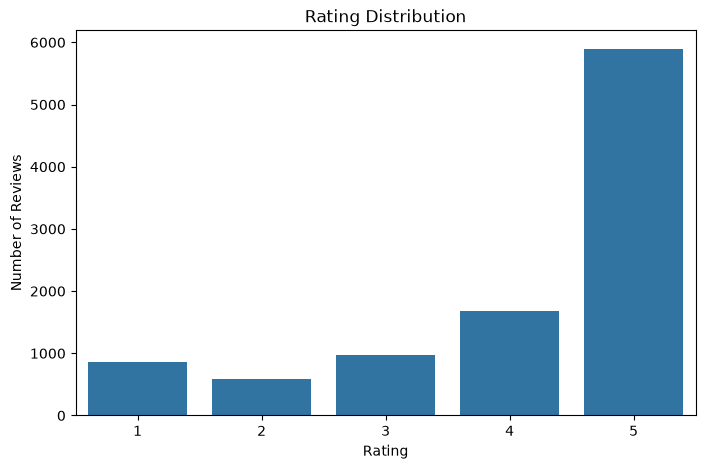

In [72]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=review,
    x="rating",
    order=[1, 2, 3, 4, 5]
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [73]:
user_activity = review["user_id"].value_counts()

print(user_activity.describe())

count    6585.000000
mean        1.518603
std         3.775118
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       165.000000
Name: count, dtype: float64


In [74]:
product_activity = review["parent_asin"].value_counts()

print(product_activity.describe())

count    7067.000000
mean        1.415028
std         1.283577
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        34.000000
Name: count, dtype: float64


In [75]:
review["rating"].value_counts(normalize=True).sort_index() * 100

rating
1     8.58
2     5.81
3     9.77
4    16.88
5    58.96
Name: proportion, dtype: float64

In [76]:
print("Users with 1 review:", (user_activity == 1).sum())
print("Users with >5 reviews:", (user_activity > 5).sum())
print("Users with >10 reviews:", (user_activity > 10).sum())

Users with 1 review: 5394
Users with >5 reviews: 113
Users with >10 reviews: 58


In [77]:
print("Products with 1 review:", (product_activity == 1).sum())
print("Products with >5 reviews:", (product_activity > 5).sum())
print("Products with >10 reviews:", (product_activity > 10).sum())

Products with 1 review: 5598
Products with >5 reviews: 109
Products with >10 reviews: 18


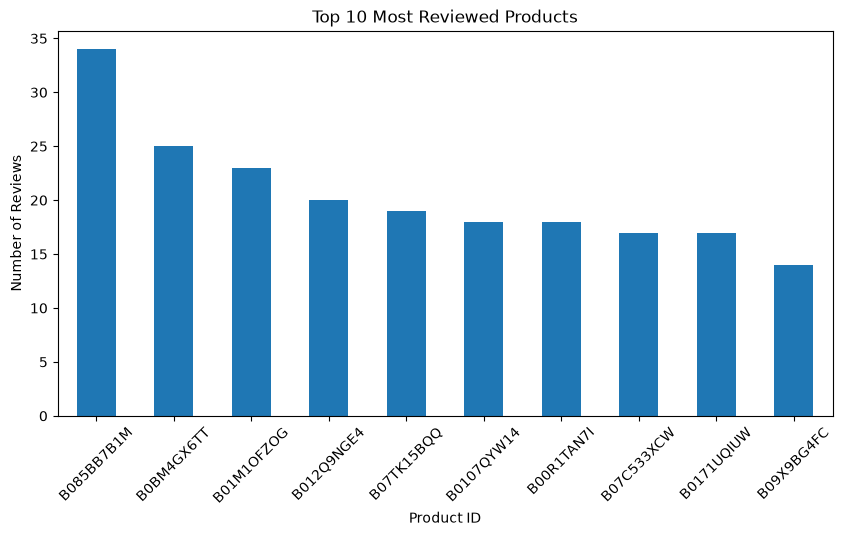

In [78]:
top_products = product_activity.head(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind="bar")

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [79]:
reviews_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"

chunks = pd.read_json(
    reviews_path,
    lines=True,
    chunksize=50000
)

print("Chunk reader created successfully")

Chunk reader created successfully


In [80]:
first_chunk = next(chunks)

print(first_chunk.shape)
first_chunk.head()

(50000, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [81]:
from collections import Counter

user_counts = Counter()
product_counts = Counter()

reviews_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"

for chunk in pd.read_json(
    reviews_path,
    lines=True,
    chunksize=50000
):
    user_counts.update(chunk["user_id"])
    product_counts.update(chunk["parent_asin"])

print("Total unique users:", len(user_counts))
print("Total unique products:", len(product_counts))

Total unique users: 631986
Total unique products: 112565


In [82]:
user_count_series = pd.Series(user_counts)
product_count_series = pd.Series(product_counts)

print("USER ACTIVITY")
print(user_count_series.describe())

print("\nPRODUCT ACTIVITY")
print(product_count_series.describe())

USER ACTIVITY
count    631986.000000
mean          1.110037
std           0.753202
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         165.000000
dtype: float64

PRODUCT ACTIVITY
count    112565.000000
mean          6.232204
std          25.189840
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1962.000000
dtype: float64


In [83]:
print("Users with >= 2 reviews:", (user_count_series >= 2).sum())
print("Users with >= 5 reviews:", (user_count_series >= 5).sum())
print("Users with >= 10 reviews:", (user_count_series >= 10).sum())
print("Users with >= 20 reviews:", (user_count_series >= 20).sum())

Users with >= 2 reviews: 48433
Users with >= 5 reviews: 1620
Users with >= 10 reviews: 330
Users with >= 20 reviews: 117


In [84]:
print("Products with >= 2 reviews:", (product_count_series >= 2).sum())
print("Products with >= 5 reviews:", (product_count_series >= 5).sum())
print("Products with >= 10 reviews:", (product_count_series >= 10).sum())
print("Products with >= 20 reviews:", (product_count_series >= 20).sum())

Products with >= 2 reviews: 64999
Products with >= 5 reviews: 27533
Products with >= 10 reviews: 13257
Products with >= 20 reviews: 6044


In [85]:
reviews_path = "../data/amazon/raw/review_categories/All_Beauty.jsonl"

filtered_chunks = []

for chunk in pd.read_json(
    reviews_path,
    lines=True,
    chunksize=50000
):
    # Keep users with at least 2 reviews
    chunk = chunk[chunk["user_id"].isin(
        user_count_series[user_count_series >= 2].index
    )]

    # Keep products with at least 5 reviews
    chunk = chunk[chunk["parent_asin"].isin(
        product_count_series[product_count_series >= 5].index
    )]

    filtered_chunks.append(
        chunk[["user_id", "parent_asin", "rating", "timestamp", "verified_purchase"]]
    )

filtered_reviews = pd.concat(filtered_chunks, ignore_index=True)

print("Filtered dataset shape:", filtered_reviews.shape)

Filtered dataset shape: (88895, 5)


In [86]:
print("Unique users:", filtered_reviews["user_id"].nunique())
print("Unique products:", filtered_reviews["parent_asin"].nunique())
print("Total interactions:", len(filtered_reviews))

Unique users: 44155
Unique products: 20987
Total interactions: 88895


In [87]:
filtered_reviews.head()


,user_id,parent_asin,rating,timestamp,verified_purchase
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,5,2020-05-05 14:08:48.923,True
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,4,2020-05-04 18:10:55.070,True
2,AFSKPY37N3C43SOI5IEXEK5JSIYA,B08P2DZB4X,5,2021-07-27 13:04:04.559,False
3,AFSKPY37N3C43SOI5IEXEK5JSIYA,B086QY6T7N,5,2021-07-18 13:21:51.145,False
4,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07RBSLNFR,5,2021-05-16 17:00:30.697,False


In [88]:
print("Missing values:")
print(filtered_reviews.isnull().sum())

print("\nDuplicate rows:")
print(filtered_reviews.duplicated().sum())

print("\nRating distribution:")
print(filtered_reviews["rating"].value_counts().sort_index())

Missing values:


user_id              0
parent_asin          0
rating               0
timestamp            0
verified_purchase    0
dtype: int64

Duplicate rows:
6223

Rating distribution:
rating
1     9227
2     4905
3     7821
4    12109
5    54833
Name: count, dtype: int64


In [89]:
print(filtered_reviews["timestamp"].head())
print(filtered_reviews["timestamp"].dtype)

0   2020-05-05 14:08:48.923
1   2020-05-04 18:10:55.070
2   2021-07-27 13:04:04.559
3   2021-07-18 13:21:51.145
4   2021-05-16 17:00:30.697
Name: timestamp, dtype: datetime64[ns]
datetime64[ns]


In [90]:
filtered_reviews = filtered_reviews.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", filtered_reviews.shape)
print("Remaining duplicates:", filtered_reviews.duplicated().sum())

Shape after removing duplicates: (82672, 5)
Remaining duplicates: 0


In [91]:
print(filtered_reviews["rating"].value_counts().sort_index())

rating
1     8256
2     4544
3     7319
4    11465
5    51088
Name: count, dtype: int64


In [92]:
print("Interactions per user:")
print(filtered_reviews["user_id"].value_counts().describe())

print("\nInteractions per product:")
print(filtered_reviews["parent_asin"].value_counts().describe())

Interactions per user:


count    44155.000000
mean         1.872313
std          1.857837
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        119.000000
Name: count, dtype: float64

Interactions per product:
count    20987.000000
mean         3.939200
std          6.743184
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        232.000000
Name: count, dtype: float64


In [93]:
# Sort interactions chronologically for each user
filtered_reviews = filtered_reviews.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)

# Users with at least 2 interactions
user_counts = filtered_reviews["user_id"].value_counts()
eligible_users = user_counts[user_counts >= 2].index

# Split
test_mask = (
    filtered_reviews["user_id"].isin(eligible_users)
    & filtered_reviews.groupby("user_id").cumcount()
      .eq(filtered_reviews.groupby("user_id")["user_id"].transform("size") - 1)
)

test_data = filtered_reviews[test_mask].copy()
train_data = filtered_reviews[~test_mask].copy()

print("Training interactions:", len(train_data))
print("Testing interactions:", len(test_data))
print("Training users:", train_data["user_id"].nunique())
print("Testing users:", test_data["user_id"].nunique())

Training interactions: 55496
Testing interactions: 27176
Training users: 44155
Testing users: 27176


In [94]:
check = (
    train_data.groupby("user_id")["timestamp"]
    .max()
    .to_frame("last_train")
    .join(
        test_data.set_index("user_id")["timestamp"]
        .rename("test_time")
    )
)

print("Users checked:", len(check))
print("Correct temporal order:",
      (check["test_time"] > check["last_train"]).sum())
print("Incorrect temporal order:",
      (check["test_time"] <= check["last_train"]).sum())

Users checked: 44155
Correct temporal order: 27176
Incorrect temporal order: 0


In [95]:
product_stats = (
    train_data
    .groupby("parent_asin")["rating"]
    .agg(["count", "mean"])
    .reset_index()
)

product_stats.columns = [
    "parent_asin",
    "rating_count",
    "average_rating"
]

product_stats.head()

,parent_asin,rating_count,average_rating
0,069267599X,3,5.0
1,1453085815,2,2.0
2,4293845755,2,1.0
3,6041134546,2,2.5
4,8674394329,2,4.0


In [96]:
product_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

,parent_asin,rating_count,average_rating
13141,B085BB7B1M,164,4.664634
17547,B0BM4GX6TT,150,4.100000
3546,B012Q9NGE4,109,4.201835
3391,B0107QYW14,107,4.084112
6004,B01M1OFZOG,95,4.115789
2619,B00R1TAN7I,81,3.913580
16804,B09C2ZW2GL,78,4.641026
226,B000X20Y4C,76,4.381579
8837,B07C533XCW,75,4.653333
7572,B074KD4PX2,73,4.191781


In [97]:
C = train_data["rating"].mean()

m = 10

product_stats["weighted_score"] = (
    (product_stats["rating_count"] /
     (product_stats["rating_count"] + m))
    * product_stats["average_rating"]
    +
    (m /
     (product_stats["rating_count"] + m))
    * C
)

print("Global average rating:", C)

Global average rating: 4.132622170967277


In [98]:
m = 10

product_stats["weighted_score"] = (
    (product_stats["rating_count"] /
     (product_stats["rating_count"] + m))
    * product_stats["average_rating"]
    +
    (m /
     (product_stats["rating_count"] + m))
    * C
)

In [99]:
top_products = product_stats.sort_values(
    "weighted_score",
    ascending=False
).head(10)

top_products

,parent_asin,rating_count,average_rating,weighted_score
16877,B09FFQT1KK,59,4.881356,4.772844
11944,B07WVBDLG9,24,5.000000,4.744889
6867,B06Y44MMT6,32,4.875000,4.698243
2004,B00KL0HV56,22,4.954545,4.697694
5398,B01I2MU2JQ,59,4.762712,4.671395
6394,B01N47XMWS,17,4.941176,4.641712
919,B007QG7G3U,17,4.941176,4.641712
15244,B08KW15N2L,14,5.000000,4.638593
13141,B085BB7B1M,164,4.664634,4.634059
6553,B06VWPZN56,35,4.771429,4.629472


In [100]:
top_product_ids = top_products["parent_asin"].tolist()

metadata[
    metadata["parent_asin"].isin(top_product_ids)
][["parent_asin", "title"]]

,parent_asin,title


In [101]:
top_product_ids = set(top_products["parent_asin"])

metadata_matches = []

for chunk in pd.read_json(
    metadata_path,
    lines=True,
    chunksize=10000
):
    matches = chunk[
        chunk["parent_asin"].isin(top_product_ids)
    ]

    if not matches.empty:
        metadata_matches.append(matches)

top_metadata = pd.concat(
    metadata_matches,
    ignore_index=True
)

print("Products found:", len(top_metadata))

Products found: 10


In [102]:
top_metadata[
    ["parent_asin", "title", "average_rating", "rating_number"]
]

,parent_asin,title,average_rating,rating_number
0,B09FFQT1KK,Sun Labs Self Tanning Mitt Applicator - 1 Sunl...,4.6,1773
1,B08KW15N2L,Original Pedi-Sox brand Toeless Socks for Pedi...,4.4,246
2,B07WVBDLG9,7Rainbows 10pcs Girls Unicorn Hair Bows On Hea...,4.6,2831
3,B06Y44MMT6,Segbeauty empty bottle 082,4.7,4251
4,B01I2MU2JQ,Sky Organics Fractionated Coconut Oil for Body...,4.7,1153
5,B085BB7B1M,Salux Nylon Japanese Beauty Skin Bath Wash Clo...,4.7,9101
6,B01N47XMWS,"1.5"" Heart Shape Kraft Paper Thank You Adhesiv...",4.8,10913
7,B06VWPZN56,"DMSO Cream With Aloe Vera - Lavender Scented, ...",4.2,2255
8,B00KL0HV56,Shea Butter -100% Pure RAW Unrefined African S...,4.0,286
9,B007QG7G3U,Coochy Shave Creme,4.4,290


collaberative filtering 

In [103]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

In [104]:
# Create unique user and product lists
users = train_data["user_id"].unique()
products = train_data["parent_asin"].unique()

# Map IDs to integer indices
user_to_index = {user: i for i, user in enumerate(users)}
product_to_index = {product: i for i, product in enumerate(products)}

In [105]:
row_indices = train_data["user_id"].map(user_to_index)
col_indices = train_data["parent_asin"].map(product_to_index)

user_item_matrix = csr_matrix(
    (
        train_data["rating"].astype(float),
        (row_indices, col_indices)
    ),
    shape=(len(users), len(products))
)

In [106]:
print("Matrix shape:", user_item_matrix.shape)
print("Number of ratings:", user_item_matrix.nnz)
print("Users:", len(users))
print("Products:", len(products))

Matrix shape: (44155, 17662)
Number of ratings: 55437
Users: 44155
Products: 17662


In [107]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose so products become rows
item_user_matrix = user_item_matrix.T

print("Item-user matrix shape:", item_user_matrix.shape)

Item-user matrix shape: (17662, 44155)


In [108]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity for the first product
similarity_scores = cosine_similarity(
    item_user_matrix[0],
    item_user_matrix
).flatten()

print("Similarity array shape:", similarity_scores.shape)
print("First 10 scores:", similarity_scores[:10])

Similarity array shape: (17662,)
First 10 scores: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [109]:
# Get indices of the most similar products
similar_items = np.argsort(similarity_scores)[::-1]

# Exclude the product itself
similar_items = similar_items[similar_items != 0]

# Select the top 5
top_5_indices = similar_items[:5]

# Get product IDs and similarity scores
for index in top_5_indices:
    product_id = products[index]
    score = similarity_scores[index]
    print(product_id, score)

B07QV3T5FT 0.5773502691896258
B07M6CDGP8 0.15713484026367724
B093QLF6ZQ 0.0
B08B4N5BXZ 0.0
B08CVTNQP1 0.0


In [110]:
similar_product_ids = [products[i] for i in top_5_indices]

similar_metadata = []

for chunk in pd.read_json(
    metadata_path,
    lines=True,
    chunksize=10000
):
    matches = chunk[
        chunk["parent_asin"].isin(similar_product_ids)
    ]

    if not matches.empty:
        similar_metadata.append(matches)

similar_products = pd.concat(
    similar_metadata,
    ignore_index=True
)

print(similar_products[["parent_asin", "title"]])

  parent_asin                                              title
0  B093QLF6ZQ  Eyelash and Brow Growth Serum Irritation Free ...
1  B08B4N5BXZ  12 Pieces Nail Polish Pen 5 ml One Step Nail G...
2  B07M6CDGP8  7 Packs Dreadlocs Faux Locs Hair Extensions 18...
3  B08CVTNQP1  Disney Frozen - Townley Girl Mega Nail Set wit...
4  B07QV3T5FT  6 Packs 18inch Striaght Goddess Locs With Curl...


In [111]:
def recommend_similar_products(product_id, top_n=5):
    product_index = product_to_index.get(product_id)

    if product_index is None:
        return "Product not found"

    scores = cosine_similarity(
        item_user_matrix[product_index],
        item_user_matrix
    ).flatten()

    similar_indices = np.argsort(scores)[::-1]

    recommendations = []

    for index in similar_indices:
        if index == product_index:
            continue

        if scores[index] <= 0:
            break

        recommendations.append({
            "parent_asin": products[index],
            "similarity": scores[index]
        })

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations)

In [112]:
recommend_similar_products(products[0], top_n=5)

,parent_asin,similarity
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135


In [113]:
def recommend_for_user(user_id, top_n=5):
    user_history = train_data[
        train_data["user_id"] == user_id
    ]

    if user_history.empty:
        return pd.DataFrame(
            columns=["parent_asin", "score"]
        )

    scores = {}

    seen_products = set(user_history["parent_asin"])

    for _, row in user_history.iterrows():
        product_id = row["parent_asin"]
        rating = row["rating"]

        product_index = product_to_index[product_id]

        # Get similarities for this product
        similarities = item_similarity.getrow(product_index)

        for index, similarity in zip(
            similarities.indices,
            similarities.data
        ):
            recommended_id = products[index]

            if recommended_id in seen_products:
                continue

            scores[recommended_id] = (
                scores.get(recommended_id, 0)
                + similarity * rating
            )

    recommendations = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    return pd.DataFrame(
        recommendations,
        columns=["parent_asin", "score"]
    )

In [114]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate sparse item-item similarities
item_similarity = cosine_similarity(
    item_user_matrix,
    dense_output=False
)

print("Similarity matrix shape:", item_similarity.shape)
print("Non-zero similarities:", item_similarity.nnz)

Similarity matrix shape: (17662, 17662)
Non-zero similarities: 152586


In [115]:
recommend_for_user(sample_user, top_n=5)


,parent_asin,score
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135


In [116]:
print(train_data.shape)
print(test_data.shape)
print(item_similarity.shape)

(55496, 5)
(27176, 5)
(17662, 17662)


In [117]:
test_data.head()

,user_id,parent_asin,rating,timestamp,verified_purchase
2,AE224HM2QAW5TTSDL2QRDERA6KMA,B0001HYKBC,4,2004-10-12 14:19:20.000,False
6,AE225THXPLSO5QQ3PHQP7SPETM2A,B07RTZMBQC,4,2019-06-27 17:41:42.843,True
9,AE22GTDGCDL6LZW7SCYBMA5VAAVA,B08XQP6X5Q,5,2021-05-27 12:09:18.118,False
13,AE22U642GBGGW7IAZSF26G434GKQ,B01F7WA2X0,1,2017-06-19 03:57:02.666,True
17,AE22XHMBOBJBXUFCTNYLFMD4UKMA,B00DT4757A,5,2016-08-13 16:50:37.000,True


In [118]:
test_data["rating"].value_counts().sort_index()

rating
1     2945
2     1573
3     2378
4     3368
5    16912
Name: count, dtype: int64

In [119]:
sample_users = test_data["user_id"].drop_duplicates().sample(
    n=100,
    random_state=42
)

print("Sample users:", len(sample_users))

Sample users: 100


In [120]:
import numpy as np

def evaluate_recommender(sample_users, k=5):
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    for user_id in sample_users:

        # Get the user's held-out interaction
        test_row = test_data[test_data["user_id"] == user_id].iloc[0]

        actual_product = test_row["parent_asin"]
        actual_rating = test_row["rating"]

        # Generate recommendations
        recommendations = recommend_for_user(user_id, top_n=k)

        if recommendations.empty:
            continue

        recommended_products = recommendations["parent_asin"].tolist()

        # Only ratings >= 4 are considered relevant
        if actual_rating >= 4:
            if actual_product in recommended_products:
                rank = recommended_products.index(actual_product) + 1

                precision = 1 / k
                recall = 1
                ndcg = 1 / np.log2(rank + 1)
            else:
                precision = 0
                recall = 0
                ndcg = 0

            precision_scores.append(precision)
            recall_scores.append(recall)
            ndcg_scores.append(ndcg)

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores),
        "NDCG@5": np.mean(ndcg_scores),
        "Users evaluated": len(precision_scores)
    }

In [121]:
results = evaluate_recommender(sample_users)

results

{'Precision@5': np.float64(0.004761904761904762),
 'Recall@5': np.float64(0.023809523809523808),
 'NDCG@5': np.float64(0.009210781124631943),
 'Users evaluated': 42}

In [122]:
from surprise import Dataset, Reader

# Define rating scale
reader = Reader(rating_scale=(1, 5))

# Prepare training data for Surprise
svd_data = train_data[["user_id", "parent_asin", "rating"]].copy()

# Load into Surprise
surprise_dataset = Dataset.load_from_df(
    svd_data,
    reader
)

print("SVD dataset prepared")
print("Interactions:", len(svd_data))

SVD dataset prepared
Interactions: 55496


In [123]:
from surprise import SVD

svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd_model.fit(surprise_dataset.build_full_trainset())

print("SVD model trained successfully")

SVD model trained successfully


In [124]:
def recommend_svd(user_id, top_n=5):
    # Products the user has already interacted with
    seen_products = set(
        train_data.loc[
            train_data["user_id"] == user_id,
            "parent_asin"
        ]
    )

    # Candidate products
    candidate_products = [
        product for product in products
        if product not in seen_products
    ]

    predictions = []

    for product_id in candidate_products:
        predicted_rating = svd_model.predict(
            user_id,
            product_id
        ).est

        predictions.append({
            "parent_asin": product_id,
            "predicted_rating": predicted_rating
        })

    recommendations = (
        pd.DataFrame(predictions)
        .sort_values(
            "predicted_rating",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations

In [125]:
sample_user = "AE224BWJ4436CVNISRJAMPHBAZJA"

svd_recommendations = recommend_svd(
    sample_user,
    top_n=5
)

svd_recommendations

,parent_asin,predicted_rating
0,B00KL0HV56,4.735522
1,B09FFQT1KK,4.695167
2,B007GQLXJI,4.639227
3,B07WVBDLG9,4.613281
4,B078JFH7QV,4.590205


In [126]:
def evaluate_svd(sample_users, k=5):
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    for user_id in sample_users:

        # Held-out interaction
        test_row = test_data[test_data["user_id"] == user_id].iloc[0]

        actual_product = test_row["parent_asin"]
        actual_rating = test_row["rating"]

        # Ignore ratings below 4
        if actual_rating < 4:
            continue

        # Get SVD recommendations
        recommendations = recommend_svd(user_id, top_n=k)

        recommended_products = recommendations["parent_asin"].tolist()

        if actual_product in recommended_products:

            rank = recommended_products.index(actual_product) + 1

            precision = 1 / k
            recall = 1
            ndcg = 1 / np.log2(rank + 1)

        else:
            precision = 0
            recall = 0
            ndcg = 0

        precision_scores.append(precision)
        recall_scores.append(recall)
        ndcg_scores.append(ndcg)

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores),
        "NDCG@5": np.mean(ndcg_scores),
        "Users evaluated": len(precision_scores)
    }


In [127]:
svd_results = evaluate_svd(sample_users)

svd_results

{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'NDCG@5': np.float64(0.0),
 'Users evaluated': 73}

In [128]:
user_id = sample_users.iloc[0]

test_item = test_data[
    test_data["user_id"] == user_id
].iloc[0]

actual_product = test_item["parent_asin"]
actual_rating = test_item["rating"]

prediction = svd_model.predict(
    user_id,
    actual_product
)

print("User:", user_id)
print("Actual product:", actual_product)
print("Actual rating:", actual_rating)
print("SVD predicted rating:", prediction.est)

User: AHONGDM5Z7WLIMV2PDJX5KTL7CZQ
Actual product: B078HCNWP3
Actual rating: 3
SVD predicted rating: 3.714641454623816


In [129]:
relevant_user = test_data[
    test_data["rating"] >= 4
]["user_id"].iloc[0]

test_item = test_data[
    test_data["user_id"] == relevant_user
].iloc[0]

print("User:", relevant_user)
print("Actual product:", test_item["parent_asin"])
print("Actual rating:", test_item["rating"])

prediction = svd_model.predict(
    relevant_user,
    test_item["parent_asin"]
)

print("SVD predicted rating:", prediction.est)

User: AE224HM2QAW5TTSDL2QRDERA6KMA
Actual product: B0001HYKBC
Actual rating: 4
SVD predicted rating: 4.242874996015429


In [130]:
recommendations = recommend_svd(
    relevant_user,
    top_n=20
)

print(recommendations)

   parent_asin  predicted_rating
0   B07C533XCW          4.943605
1   B06Y44MMT6          4.884030
2   B00LWHUJLU          4.876176
3   B07WVBDLG9          4.846707
4   B006WZD7FW          4.841368
5   B07V6F1TK2          4.836390
6   B001B9S416          4.822754
7   B079CW539Y          4.815712
8   B01M07CRQR          4.812575
9   B09P9HMMLM          4.809990
10  B01J5ONDPK          4.788746
11  B01N7XE0A4          4.781845
12  B00OXDWFG2          4.774938
13  B07VQR3W3Z          4.772889
14  B08TCBP8HV          4.768303
15  B00I4ZTCH0          4.756175
16  B007QG7G3U          4.753477
17  B01N1NNI81          4.749955
18  B07NN4VC8Z          4.749261
19  B01N5CJPSX          4.748662


In [131]:
actual_product = test_item["parent_asin"]

all_recommendations = recommend_svd(
    relevant_user,
    top_n=len(products)
)

actual_rank = (
    all_recommendations
    .index[
        all_recommendations["parent_asin"] == actual_product
    ][0] + 1
)

print("Actual product:", actual_product)
print("Actual rating:", test_item["rating"])
print("SVD predicted rating:", prediction.est)
print("Rank of actual product:", actual_rank)

Actual product: B0001HYKBC
Actual rating: 4
SVD predicted rating: 4.242874996015429
Rank of actual product: 5647


In [132]:

def evaluate_svd_optimized(sample_users, k=5):
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    evaluated_users = 0

    all_products = products

    for user_id in sample_users:

        # Get held-out test interaction
        test_row = test_data[
            test_data["user_id"] == user_id
        ].iloc[0]

        actual_product = test_row["parent_asin"]
        actual_rating = test_row["rating"]

        # Only evaluate relevant items
        if actual_rating < 4:
            continue

        # Products already seen during training
        seen_products = set(
            train_data.loc[
                train_data["user_id"] == user_id,
                "parent_asin"
            ]
        )

        # Candidate products
        candidates = [
            product for product in all_products
            if product not in seen_products
        ]

        # Predict ratings
        predicted_scores = []

        for product_id in candidates:
            prediction = svd_model.predict(
                user_id,
                product_id
            ).est

            predicted_scores.append(
                (product_id, prediction)
            )

        # Sort by predicted rating
        predicted_scores.sort(
            key=lambda x: x[1],
            reverse=True
        )

        # Top-K products
        top_k = [
            product_id
            for product_id, score in predicted_scores[:k]
        ]

        evaluated_users += 1

        # Check whether actual product is in Top-K
        if actual_product in top_k:

            rank = top_k.index(actual_product) + 1

            precision_scores.append(1 / k)
            recall_scores.append(1)

            ndcg_scores.append(
                1 / np.log2(rank + 1)
            )

        else:
            precision_scores.append(0)
            recall_scores.append(0)
            ndcg_scores.append(0)

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores),
        "NDCG@5": np.mean(ndcg_scores),
        "Users evaluated": evaluated_users
    }

In [133]:
svd_results = evaluate_svd_optimized(
    sample_users,
    k=5
)

svd_results

{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'NDCG@5': np.float64(0.0),
 'Users evaluated': 73}

In [134]:
print("User factors:", svd_model.pu.shape)
print("Product factors:", svd_model.qi.shape)

User factors: (44155, 100)
Product factors: (17662, 100)


In [135]:
def recommend_svd_fast(user_id, top_n=5):
    # Check user exists
    if user_id not in user_to_index_svd:
        return pd.DataFrame(
            columns=["parent_asin", "predicted_rating"]
        )

    user_index = user_to_index_svd[user_id]

    # User latent vector
    user_vector = svd_model.pu[user_index]

    # Predicted ratings from latent factors
    scores = np.dot(
        svd_model.qi,
        user_vector
    )

    # Add SVD biases
    scores += svd_model.bu[user_index]
    scores += svd_model.bi
    scores += svd_model.trainset.global_mean

    # Products already seen by user
    seen_products = set(
        train_data.loc[
            train_data["user_id"] == user_id,
            "parent_asin"
        ]
    )

    # Remove already-seen products
    for product_id in seen_products:
        if product_id in product_to_index_svd:
            scores[
                product_to_index_svd[product_id]
            ] = -np.inf

    # Get Top-N
    top_indices = np.argsort(scores)[-top_n:][::-1]

    return pd.DataFrame({
        "parent_asin": [
            products_svd[i] for i in top_indices
        ],
        "predicted_rating": [
            scores[i] for i in top_indices
        ]
    })

In [136]:
user_to_index_svd = {
    user_id: svd_model.trainset.to_inner_uid(user_id)
    for user_id in train_data["user_id"].unique()
}

product_to_index_svd = {
    product_id: svd_model.trainset.to_inner_iid(product_id)
    for product_id in train_data["parent_asin"].unique()
}

products_svd = [
    svd_model.trainset.to_raw_iid(i)
    for i in range(svd_model.trainset.n_items)
]

In [137]:
recommend_svd_fast(
    sample_user,
    top_n=5
)

,parent_asin,predicted_rating
0,B00KL0HV56,4.735522
1,B09FFQT1KK,4.695167
2,B007GQLXJI,4.639227
3,B07WVBDLG9,4.613281
4,B078JFH7QV,4.590205


In [138]:
def evaluate_svd_fast(sample_users, k=5):

    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    evaluated_users = 0

    for user_id in sample_users:

        # Get held-out interaction
        test_row = test_data[
            test_data["user_id"] == user_id
        ].iloc[0]

        actual_product = test_row["parent_asin"]
        actual_rating = test_row["rating"]

        # Only 4 and 5 star ratings are relevant
        if actual_rating < 4:
            continue

        recommendations = recommend_svd_fast(
            user_id,
            top_n=k
        )

        recommended_products = (
            recommendations["parent_asin"].tolist()
        )

        evaluated_users += 1

        if actual_product in recommended_products:

            rank = (
                recommended_products.index(actual_product) + 1
            )

            precision_scores.append(1 / k)
            recall_scores.append(1)

            ndcg_scores.append(
                1 / np.log2(rank + 1)
            )

        else:

            precision_scores.append(0)
            recall_scores.append(0)
            ndcg_scores.append(0)

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores),
        "NDCG@5": np.mean(ndcg_scores),
        "Users evaluated": evaluated_users
    }

In [139]:
svd_results_fast = evaluate_svd_fast(
    sample_users,
    k=5
)

svd_results_fast

{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'NDCG@5': np.float64(0.0),
 'Users evaluated': 73}

In [140]:
from surprise import accuracy

testset = [
    (row["user_id"], row["parent_asin"], row["rating"])
    for _, row in test_data.iterrows()
]

svd_predictions = svd_model.test(testset)

print("SVD RMSE:")
accuracy.rmse(svd_predictions)

print("SVD MAE:")
accuracy.mae(svd_predictions)

SVD RMSE:
RMSE: 1.3358
SVD MAE:
MAE:  1.0622


np.float64(1.0622234768499297)

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

global_mean = train_data["rating"].mean()

actual_ratings = test_data["rating"]

baseline_predictions = np.full(
    len(test_data),
    global_mean
)

baseline_mae = mean_absolute_error(
    actual_ratings,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_ratings,
        baseline_predictions
    )
)

print("Global Mean:", global_mean)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Global Mean: 4.132622170967277
Baseline MAE: 1.1182413823745048
Baseline RMSE: 1.3817833197886653


In [142]:
from sklearn.neighbors import NearestNeighbors

In [143]:
import sys
import numpy
import scipy
import sklearn

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.3
SciPy: 1.16.3
Scikit-learn: 1.9.1


In [144]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest import works")

Random Forest import works


In [145]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors

print("scikit-learn is working")

scikit-learn is working


In [146]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=6
)

knn_model.fit(item_user_matrix)

print("KNN model trained successfully")

KNN model trained successfully


In [147]:
def recommend_knn_for_product(product_id, top_n=5):
    product_index = product_to_index.get(product_id)

    if product_index is None:
        return "Product not found"

    distances, indices = knn_model.kneighbors(
        item_user_matrix[product_index],
        n_neighbors=top_n + 1
    )

    recommendations = []

    for distance, index in zip(distances[0], indices[0]):
        if index == product_index:
            continue

        recommendations.append({
            "parent_asin": products[index],
            "similarity": 1 - distance
        })

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations)

In [148]:
sample_product = train_data["parent_asin"].iloc[0]

print("Sample product:", sample_product)

recommend_knn_for_product(sample_product, top_n=5)

Sample product: B07RJ36BZQ


,parent_asin,similarity
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135
2,B08B4N5BXZ,0.000000
3,B088KPJ1XL,0.000000
4,B081T859ZD,0.000000


In [149]:
def recommend_knn_for_product(product_id, top_n=5):
    product_index = product_to_index.get(product_id)

    if product_index is None:
        return "Product not found"

    distances, indices = knn_model.kneighbors(
        item_user_matrix[product_index],
        n_neighbors=top_n + 10
    )

    recommendations = []

    for distance, index in zip(distances[0], indices[0]):
        if index == product_index:
            continue

        similarity = 1 - distance

        # Ignore products with zero similarity
        if similarity <= 0:
            continue

        recommendations.append({
            "parent_asin": products[index],
            "similarity": similarity
        })

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations)

In [150]:
sample_product = train_data["parent_asin"].iloc[0]

recommend_knn_for_product(sample_product, top_n=5)

,parent_asin,similarity
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135


In [151]:
def recommend_knn_for_user(user_id, top_n=5):
    user_history = train_data[
        train_data["user_id"] == user_id
    ]

    if user_history.empty:
        return pd.DataFrame(
            columns=["parent_asin", "score"]
        )

    seen_products = set(user_history["parent_asin"])
    scores = {}

    for _, row in user_history.iterrows():

        product_id = row["parent_asin"]
        rating = row["rating"]

        product_index = product_to_index.get(product_id)

        if product_index is None:
            continue

        distances, indices = knn_model.kneighbors(
            item_user_matrix[product_index],
            n_neighbors=11
        )

        for distance, index in zip(
            distances[0],
            indices[0]
        ):

            recommended_product = products[index]

            # Don't recommend products already purchased/rated
            if recommended_product in seen_products:
                continue

            similarity = 1 - distance

            if similarity <= 0:
                continue

            # Rating-weighted similarity
            scores[recommended_product] = (
                scores.get(recommended_product, 0)
                + similarity * rating
            )

    recommendations = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    return pd.DataFrame(
        recommendations,
        columns=["parent_asin", "score"]
    )

In [152]:
sample_user = "AE224BWJ4436CVNISRJAMPHBAZJA"

recommend_knn_for_user(
    sample_user,
    top_n=5
)

,parent_asin,score
0,B07QV3T5FT,0.577350
1,B07M6CDGP8,0.157135


In [153]:
def evaluate_knn(sample_users, k=5):
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    for user_id in sample_users:

        user_test = test_data[
            test_data["user_id"] == user_id
        ]

        if user_test.empty:
            continue

        test_row = user_test.iloc[0]

        actual_product = test_row["parent_asin"]
        actual_rating = test_row["rating"]

        # Only ratings >= 4 are considered relevant
        if actual_rating < 4:
            continue

        recommendations = recommend_knn_for_user(
            user_id,
            top_n=k
        )

        if recommendations.empty:
            continue

        recommended_products = (
            recommendations["parent_asin"].tolist()
        )

        if actual_product in recommended_products:

            rank = (
                recommended_products.index(actual_product) + 1
            )

            precision = 1 / k
            recall = 1
            ndcg = 1 / np.log2(rank + 1)

        else:

            precision = 0
            recall = 0
            ndcg = 0

        precision_scores.append(precision)
        recall_scores.append(recall)
        ndcg_scores.append(ndcg)

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores),
        "NDCG@5": np.mean(ndcg_scores),
        "Users evaluated": len(precision_scores)
    }

In [154]:
knn_results = evaluate_knn(
    sample_users,
    k=5
)

knn_results

{'Precision@5': np.float64(0.004761904761904762),
 'Recall@5': np.float64(0.023809523809523808),
 'NDCG@5': np.float64(0.009210781124631943),
 'Users evaluated': 42}

In [155]:
model_comparison = pd.DataFrame([
    {
        "Model": "Popularity",
        "Precision@5": np.nan,
        "Recall@5": np.nan,
        "NDCG@5": np.nan,
        "MAE": np.nan,
        "RMSE": np.nan
    },
    {
        "Model": "Item-CF",
        "Precision@5": 0.0047619,
        "Recall@5": 0.0238095,
        "NDCG@5": 0.0092108,
        "MAE": np.nan,
        "RMSE": np.nan
    },
    {
        "Model": "KNN",
        "Precision@5": 0.0047619,
        "Recall@5": 0.0238095,
        "NDCG@5": 0.0092108,
        "MAE": np.nan,
        "RMSE": np.nan
    },
    {
        "Model": "SVD",
        "Precision@5": 0.0,
        "Recall@5": 0.0,
        "NDCG@5": 0.0,
        "MAE": 1.0622,
        "RMSE": 1.3358
    }
])

model_comparison

,Model,Precision@5,Recall@5,NDCG@5,MAE,RMSE
0,Popularity,NaN,NaN,NaN,NaN,NaN
1,Item-CF,0.004762,0.02381,0.009211,NaN,NaN
2,KNN,0.004762,0.02381,0.009211,NaN,NaN
3,SVD,0.000000,0.00000,0.000000,1.0622,1.3358


In [156]:
def build_popularity_model(train_data):
    product_stats = (
        train_data
        .groupby("parent_asin")["rating"]
        .agg(["count", "mean"])
        .reset_index()
    )

    C = train_data["rating"].mean()
    m = 10

    product_stats["score"] = (
        (product_stats["count"] / (product_stats["count"] + m))
        * product_stats["mean"]
        +
        (m / (product_stats["count"] + m))
        * C
    )

    return product_stats.sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)


popularity_model = build_popularity_model(train_data)

popularity_model.head(10)

,parent_asin,count,mean,score
0,B09FFQT1KK,59,4.881356,4.772844
1,B07WVBDLG9,24,5.000000,4.744889
2,B06Y44MMT6,32,4.875000,4.698243
3,B00KL0HV56,22,4.954545,4.697694
4,B01I2MU2JQ,59,4.762712,4.671395
5,B01N47XMWS,17,4.941176,4.641712
6,B007QG7G3U,17,4.941176,4.641712
7,B08KW15N2L,14,5.000000,4.638593
8,B085BB7B1M,164,4.664634,4.634059
9,B06VWPZN56,35,4.771429,4.629472


In [157]:
def recommend_popularity(top_n=5):
    return popularity_model.head(top_n)["parent_asin"].tolist()


def evaluate_popularity(sample_users, k=5):
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    recommendations = recommend_popularity(k)

    for user_id in sample_users:

        user_test = test_data[
            test_data["user_id"] == user_id
        ]

        if user_test.empty:
            continue

        test_row = user_test.iloc[0]

        actual_product = test_row["parent_asin"]
        actual_rating = test_row["rating"]

        # Only ratings >= 4 are relevant
        if actual_rating < 4:
            continue

        if actual_product in recommendations:

            rank = recommendations.index(actual_product) + 1

            precision = 1 / k
            recall = 1
            ndcg = 1 / np.log2(rank + 1)

        else:

            precision = 0
            recall = 0
            ndcg = 0

        precision_scores.append(precision)
        recall_scores.append(recall)
        ndcg_scores.append(ndcg)

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores),
        "NDCG@5": np.mean(ndcg_scores),
        "Users evaluated": len(precision_scores)
    }

In [158]:
popularity_results = evaluate_popularity(
    sample_users,
    k=5
)

popularity_results

{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'NDCG@5': np.float64(0.0),
 'Users evaluated': 73}

In [159]:
def calculate_knn_coverage(sample_users, k=5):

    recommended_products = set()

    for user_id in sample_users:

        recommendations = recommend_knn_for_user(
            user_id,
            top_n=k
        )

        if not recommendations.empty:
            recommended_products.update(
                recommendations["parent_asin"]
            )

    total_products = len(products)

    coverage = (
        len(recommended_products) / total_products
    ) * 100

    return {
        "Unique recommended products": len(recommended_products),
        "Total products": total_products,
        "Coverage (%)": coverage
    }


knn_coverage = calculate_knn_coverage(
    sample_users,
    k=5
)

knn_coverage

{'Unique recommended products': 186,
 'Total products': 17662,
 'Coverage (%)': 1.0531083682482165}

In [160]:
relevant_test = test_data[
    test_data["rating"] >= 4
].copy()

relevant_counts = (
    relevant_test
    .groupby("user_id")
    .size()
)

print("Relevant test interactions:", len(relevant_test))
print("Users with relevant test items:", relevant_counts.shape[0])
print("Average relevant items per user:", relevant_counts.mean())
print("Maximum relevant items for one user:", relevant_counts.max())

Relevant test interactions: 20280
Users with relevant test items: 20280
Average relevant items per user: 1.0
Maximum relevant items for one user: 1


In [161]:
sample_users_1000 = test_data["user_id"].drop_duplicates().sample(
    n=1000,
    random_state=42
)

print("Users selected:", len(sample_users_1000))

Users selected: 1000


In [162]:
item_cf_results_1000 = evaluate_recommender(
    sample_users_1000,
    k=5
)

item_cf_results_1000

{'Precision@5': np.float64(0.0036529680365296807),
 'Recall@5': np.float64(0.0182648401826484),
 'NDCG@5': np.float64(0.013023703590279627),
 'Users evaluated': 438}

In [163]:
import json
import pandas as pd

metadata_path = "../data/amazon/raw/meta_categories/meta_All_Beauty.jsonl"

metadata = []

with open(metadata_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            metadata.append(json.loads(line))
        except json.JSONDecodeError:
            continue

metadata_df = pd.DataFrame(metadata)

print("Metadata shape:", metadata_df.shape)
print("Columns:")
print(metadata_df.columns.tolist())

Metadata shape: (112590, 14)
Columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


In [164]:
metadata_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,None


In [165]:
product_catalog = metadata_df[
    [
        "parent_asin",
        "title",
        "average_rating",
        "rating_number",
        "price",
        "images",
        "store"
    ]
].copy()

print("Product catalog shape:", product_catalog.shape)
product_catalog.head()

Product catalog shape: (112590, 7)


,parent_asin,title,average_rating,rating_number,price,images,store
0,B01CUPMQZE,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,Howard Products
1,B076WQZGPM,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,Yes To
2,B000B658RI,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,Levine Health Products
3,B088FKY3VD,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,Cherioll
4,B07NGFDN6G,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,Precision


In [166]:
sample_images = product_catalog.iloc[0]["images"]

print(sample_images)

[{'thumb': 'https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41qfjSfqNyL.jpg', 'variant': 'MAIN', 'hi_res': None}, {'thumb': 'https://m.media-amazon.com/images/I/41w2yznfuZL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41w2yznfuZL.jpg', 'variant': 'PT01', 'hi_res': 'https://m.media-amazon.com/images/I/71i77AuI9xL._SL1500_.jpg'}]


In [167]:
import re

def extract_image_url(images):
    if not isinstance(images, list) or len(images) == 0:
        return None

    image = images[0]

    if not isinstance(image, dict):
        return None

    url = (
        image.get("hi_res")
        or image.get("large")
        or image.get("thumb")
    )

    if not url:
        return None

    # Extract URL from Markdown format: [text](URL)
    match = re.search(r"\((https?://[^)]+)\)", url)

    if match:
        return match.group(1)

    return url


product_catalog["image_url"] = product_catalog["images"].apply(
    extract_image_url
)

product_catalog[
    ["parent_asin", "title", "image_url"]
].head()

,parent_asin,title,image_url
0,B01CUPMQZE,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",https://m.media-amazon.com/images/I/41qfjSfqNy...
1,B076WQZGPM,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,https://m.media-amazon.com/images/I/71g1lP0pMb...
2,B000B658RI,Eye Patch Black Adult with Tie Band (6 Per Pack),https://m.media-amazon.com/images/I/31bz+uqzWC...
3,B088FKY3VD,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",https://m.media-amazon.com/images/I/71GJhXQGvy...
4,B07NGFDN6G,Precision Plunger Bars for Cartridge Grips – 9...,https://m.media-amazon.com/images/I/31TgqAZ8kQ...


In [168]:
print(
    "Products with images:",
    product_catalog["image_url"].notna().sum()
)

print(
    "Products without images:",
    product_catalog["image_url"].isna().sum()
)

Products with images: 112590
Products without images: 0


In [169]:
product_lookup = product_catalog.set_index("parent_asin")

In [170]:
def get_product_details(product_id):
    if product_id not in product_lookup.index:
        return {
            "parent_asin": product_id,
            "title": "Product information unavailable",
            "average_rating": None,
            "rating_number": None,
            "price": None,
            "image_url": None,
            "store": None
        }

    product = product_lookup.loc[product_id]

    return {
        "parent_asin": product_id,
        "title": product["title"],
        "average_rating": product["average_rating"],
        "rating_number": product["rating_number"],
        "price": product["price"],
        "image_url": product["image_url"],
        "store": product["store"]
    }

In [171]:
get_product_details("B07QV3T5FT")

{'parent_asin': 'B07QV3T5FT',
 'title': '6 Packs 18inch Striaght Goddess Locs With Curly Ends Faux Locs Crochet Twist Hair Soft Synthetic Braiding Hair Extension Wavy Faux Locs Twist Hair (18inch, T1b-99J)',
 'average_rating': np.float64(4.0),
 'rating_number': np.int64(54),
 'price': np.float64(nan),
 'image_url': 'https://m.media-amazon.com/images/I/81urKi17NHL._SL1480_.jpg',
 'store': 'AGO'}

In [172]:
def clean_image_url(url):
    if not isinstance(url, str):
        return None

    match = re.search(r"\((https?://[^)]+)\)", url)

    if match:
        return match.group(1)

    return url


product_catalog["image_url"] = (
    product_catalog["image_url"]
    .apply(clean_image_url)
)

In [173]:
product = get_product_details("B07QV3T5FT")

print("Title:", product["title"])
print("Rating:", product["average_rating"])
print("Store:", product["store"])
print("Image:", product["image_url"])

Title: 6 Packs 18inch Striaght Goddess Locs With Curly Ends Faux Locs Crochet Twist Hair Soft Synthetic Braiding Hair Extension Wavy Faux Locs Twist Hair (18inch, T1b-99J)
Rating: 4.0
Store: AGO
Image: https://m.media-amazon.com/images/I/81urKi17NHL._SL1480_.jpg


In [174]:
def clean_image_url(url):
    if not isinstance(url, str):
        return None

    # Markdown format: [text](actual_url)
    if "](" in url and url.endswith(")"):
        return url.split("](")[1][:-1]

    return url


product_catalog["image_url"] = (
    product_catalog["image_url"]
    .apply(clean_image_url)
)

In [175]:
product_lookup = product_catalog.set_index("parent_asin")

In [176]:
product = get_product_details("B07QV3T5FT")

print("Image:", product["image_url"])

Image: https://m.media-amazon.com/images/I/81urKi17NHL._SL1480_.jpg


In [177]:
import re

def clean_image_url(url):
    if not isinstance(url, str):
        return None

    # Find the actual URL inside Markdown
    match = re.search(r'https?://[^)\]]+', url)

    if match:
        return match.group(0)

    return url

In [178]:
product_catalog["image_url"] = (
    product_catalog["image_url"]
    .apply(clean_image_url)
)

In [179]:
product_lookup = product_catalog.set_index("parent_asin")

In [180]:
product = get_product_details("B07QV3T5FT")

print(product["image_url"])

https://m.media-amazon.com/images/I/81urKi17NHL._SL1480_.jpg


In [181]:
print("User factors:", svd_model.pu.shape)
print("Product factors:", svd_model.qi.shape)

User factors: (44155, 100)
Product factors: (17662, 100)


In [182]:
def clean_image_url(url):
    if not isinstance(url, str):
        return None

    if "](" in url:
        url = url.split("](", 1)[1]

        if url.endswith(")"):
            url = url[:-1]

    return url

In [183]:
product_catalog["image_url"] = (
    product_catalog["image_url"]
    .apply(clean_image_url)
)

In [184]:
product_lookup = product_catalog.set_index("parent_asin")

In [185]:
print(product_catalog.loc[
    product_catalog["parent_asin"] == "B07QV3T5FT",
    "image_url"
].iloc[0])

https://m.media-amazon.com/images/I/81urKi17NHL._SL1480_.jpg


In [186]:
def get_product_details(product_id):
    if product_id not in product_lookup.index:
        return {
            "parent_asin": product_id,
            "title": "Product information unavailable",
            "average_rating": None,
            "rating_number": None,
            "price": None,
            "image_url": None,
            "store": None
        }

    product = product_lookup.loc[product_id]

    image_url = product["image_url"]

    # Extract URL from Markdown-style image link
    if isinstance(image_url, str) and "](" in image_url:
        image_url = image_url.split("](", 1)[1]
        image_url = image_url.rstrip(")")

    return {
        "parent_asin": product_id,
        "title": product["title"],
        "average_rating": product["average_rating"],
        "rating_number": product["rating_number"],
        "price": product["price"],
        "image_url": image_url,
        "store": product["store"]
    }

In [187]:
product = get_product_details("B07QV3T5FT")

print(product["image_url"])

https://m.media-amazon.com/images/I/81urKi17NHL._SL1480_.jpg


In [188]:
import joblib

joblib.dump(
    svd_model,
    "../models/svd_model.pkl"
)

print("SVD model saved successfully")

SVD model saved successfully


In [189]:
joblib.dump(
    knn_model,
    "../models/knn_model.pkl"
)

print("KNN model saved successfully")

KNN model saved successfully


In [190]:
from scipy.sparse import save_npz

save_npz(
    "../models/item_similarity.npz",
    item_similarity
)

print("Item-CF similarity matrix saved successfully")

Item-CF similarity matrix saved successfully


In [191]:
joblib.dump(
    {
        "user_to_index": user_to_index,
        "product_to_index": product_to_index,
        "products": products
    },
    "../models/item_cf_mappings.pkl"
)

print("Item-CF mappings saved successfully")

Item-CF mappings saved successfully


In [192]:
product_catalog.to_pickle(
    "../models/product_catalog.pkl"
)

print("Product catalog saved successfully")

Product catalog saved successfully


In [193]:
from scipy.sparse import save_npz

save_npz(
    "../models/item_user_matrix.npz",
    item_user_matrix
)

print("Item-user matrix saved.")
print(item_user_matrix.shape)

Item-user matrix saved.
(17662, 44155)
